In [97]:
import torch
import matplotlib.pyplot as plt
import numpy as np


image_tensor = torch.load('image_tensor copy 2.pt')
mask_tensor = torch.load('mask_tensor copy 2.pt')

C:\Users\madsp\AppData\Local\Temp\ipykernel_17132\1254653755.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  image_tensor = torch.load('image_tensor copy 2.pt')
C:\Users

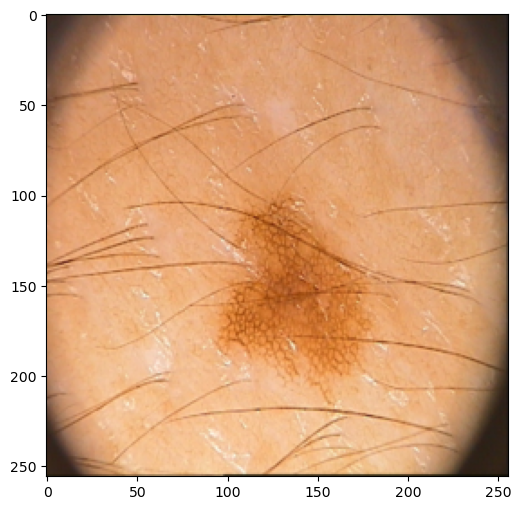

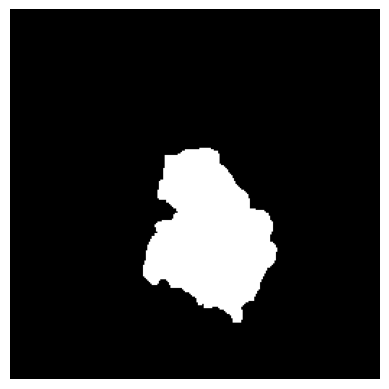

In [98]:
def plot_figure(image_tensor):
    
    image_numpy = image_tensor.permute(1, 2, 0).numpy()
    plt.figure(figsize=(6,6))
    plt.imshow(image_numpy)
    plt.show()

def plot_mask(mask_tensor):

    mask_np = mask_tensor.squeeze().cpu().numpy()
    plt.imshow(mask_np, cmap='gray')
    plt.axis('off')  
    plt.show()

plot_figure(image_tensor)
plot_mask(mask_tensor)


In [99]:
def draw_circle_on_tensor(tensor, center, radius, Bcolor):

    tensor_np = tensor.permute(1, 2, 0).cpu().numpy()  
    height, width, _ = tensor_np.shape


    for y in range(max(0, center[0] - radius), min(height, center[0] + radius + 1)):
        for x in range(max(0, center[1] - radius), min(width, center[1] + radius + 1)):
            if (x - center[1])**2 + (y - center[0])**2 <= radius**2:
                if Bcolor == True:
                    tensor_np[y, x, :] = [1.0, 0.0, 0.0]  
                else:
                    tensor_np[y, x, :] = [0.0, 1.0, 0.0]

    modified_tensor = torch.tensor(tensor_np).permute(2, 0, 1)

    return modified_tensor

def add_point(mask_tensor, image_tensor, num_circles, radius):
    torch.manual_seed(42)


    for _ in range(num_circles):
        zero_indices = (mask_tensor.squeeze() == 0).nonzero(as_tuple=True)
        one_indices = (mask_tensor.squeeze() == 1).nonzero(as_tuple=True)

        if len(zero_indices[0]) > 0:
            random_index = torch.randint(0, len(zero_indices[0]), (1,)).item()
            selected_zero = (zero_indices[0][random_index].item(), zero_indices[1][random_index].item())

            image_tensor = draw_circle_on_tensor(image_tensor, selected_zero, radius, True)

        if len(one_indices[0]) > 0:
            random_index = torch.randint(0, len(one_indices[0]), (1,)).item()
            selected_one = (one_indices[0][random_index].item(), one_indices[1][random_index].item())

            image_tensor = draw_circle_on_tensor(image_tensor, selected_one, radius, False)

    return image_tensor

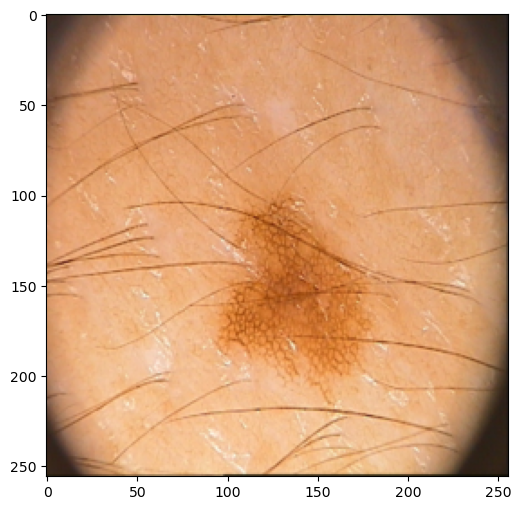

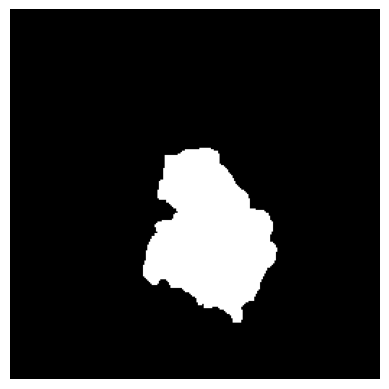

In [100]:
#image_tensor = add_point(mask_tensor, image_tensor, 20, 6)

plot_figure(image_tensor)
plot_mask(mask_tensor)

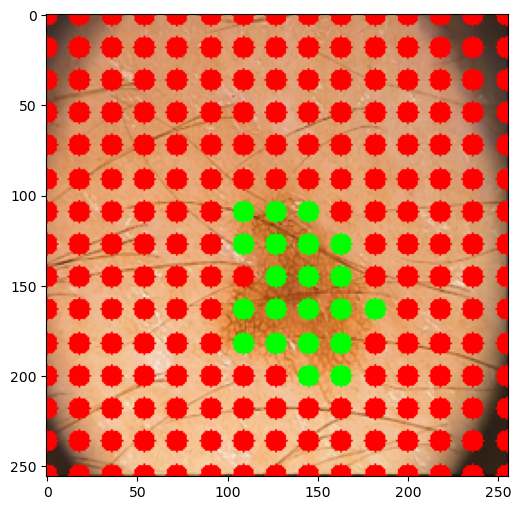

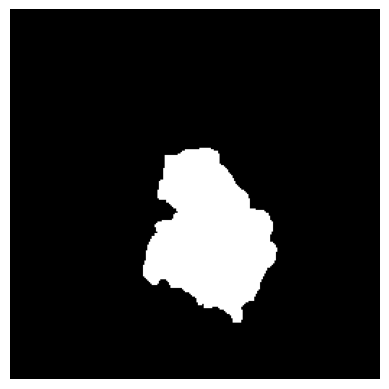

In [101]:
def add_point(mask_tensor, image_tensor, num, radius):
    torch.manual_seed(42)
    _, height, width = mask_tensor.shape

    for i in np.linspace(0,height - 1, num, dtype=int):
        for j in np.linspace(0,width - 1, num, dtype=int):
            if mask_tensor[:,i,j] == 0:
                image_tensor = draw_circle_on_tensor(image_tensor, (i,j), radius, True)
            else:
                image_tensor = draw_circle_on_tensor(image_tensor, (i,j), radius, False)

            

    return image_tensor





image_tensor = add_point(mask_tensor, image_tensor, 15, 6)

plot_figure(image_tensor)
plot_mask(mask_tensor)